# HDT 2: Probabilidad, MLE y MAP

**Ciencia de Datos, Sección A** · Asignada: jueves 6 de agosto · **Entrega: jueves 13 de agosto, 23:59**

**Nombre:** Ana Sofía Eggenberger

Completar las celdas marcadas con `# ¿Qué va aquí?`. Cada ejercicio incluye una verificación comentada: descomentar para comprobar el resultado. Antes de entregar: **Kernel → Restart & Run All** (un notebook que no corre de arriba a abajo pierde 0.5 pts).

AI: resolver sin AI. Si se usó para entender un concepto, anotarlo en la mini-bitácora del final.

## Setup

Dependencias: `pip install numpy pandas matplotlib requests`. El rango de fechas es fijo (1 de mayo al 31 de julio de 2026): todos trabajan con los mismos 92 días y las verificaciones son exactas.

In [41]:
import json
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

AZUL, ROJO, GRIS, LINEA = "#3A6EA5", "#B04A2E", "#75808E", "#E0E4EA"

def eje_limpio(ax):
    ax.grid(color=LINEA, lw=0.6, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

URL = "https://archive-api.open-meteo.com/v1/archive"

## Parte A · Adquirir los datos (0.6 pt)

Clima observado de Ciudad de Guatemala (14.63, -90.51), del **2026-05-01** al **2026-07-31**, con las variables diarias `temperature_2m_max` y `precipitation_sum`, zona horaria `America/Guatemala`.

### Ejercicio 1 (0.15): descargar de la API

Armar el diccionario `params` con latitud, longitud, fechas, variables diarias (las dos en una sola cadena separada por coma) y zona horaria. Hacer el request y validar.

In [42]:
params = {
    "latitude": 14.63,
    "longitude": -90.51,
    "start_date": "2026-05-01",
    "end_date": "2026-07-31",
    "daily": "temperature_2m_max,precipitation_sum",
    "timezone": "America/Guatemala"
}

r = requests.get(URL, params=params, timeout=20)
print(r.status_code)
datos = r.json()

# Verificación (descomentar):
assert r.status_code == 200
assert list(datos["daily"].keys()) == ["time", "temperature_2m_max", "precipitation_sum"]

200


### Ejercicio 2 (0.15): JSON a DataFrame

Crear `clima` a partir de `datos["daily"]` y convertir la columna `time` a datetime.

In [43]:
clima = pd.DataFrame(datos["daily"])

# convertir time a datetime
clima["time"] = pd.to_datetime(clima["time"])

clima.head()

# Verificación (descomentar):
assert clima.shape == (92, 3)
assert clima.isna().sum().sum() == 0
assert str(clima["time"].dtype).startswith("datetime")

### Ejercicio 3 (0.15): días con lluvia

(a) Columna booleana `llovio`: lluvia **mayor a 1.0 mm** (estricto). (b) `k` = días con lluvia y `n` = total de días. (c) El día con la lluvia máxima: fecha y milímetros.

In [44]:
clima["llovio"] = clima["precipitation_sum"] > 1

k = int(clima["llovio"].sum())
n = len(clima)

idx_max = clima["precipitation_sum"].idxmax()
dia_max_lluvia = clima.loc[idx_max, "time"]
lluvia_max = clima.loc[idx_max, "precipitation_sum"]

print("Días con lluvia:", k)
print("Total de días:", n)
print("Día con mayor lluvia:", dia_max_lluvia)
print("Lluvia máxima:", lluvia_max, "mm")

# Verificación:
assert int(clima["llovio"].sum()) == 51 and len(clima) == 92

Días con lluvia: 51
Total de días: 92
Día con mayor lluvia: 2026-06-22 00:00:00
Lluvia máxima: 27.7 mm


### Ejercicio 4 (0.15): ficha de procedencia

Construir el diccionario `ficha` con las llaves `fuente`, `url`, `rango_fechas`, `fecha_descarga`, `filas` y `variables`. Guardarlo como `clima_procedencia.json` y guardar `clima` como `clima_gt.csv`.

In [45]:
ficha = {
    "fuente": "Open-Meteo (ERA5)",
    "url": URL,
    "rango_fechas": {
        "inicio": "2026-05-01",
        "fin": "2026-07-31"
    },
    "fecha_descarga": pd.Timestamp.today().strftime("%Y-%m-%d"),
    "filas": len(clima),
    "variables": list(clima.columns)
}

import json

with open("clima_procedencia.json", "w") as archivo:
    json.dump(ficha, archivo, indent=4)

clima.to_csv("clima_gt.csv", index=False)

# Verificación (descomentar)
import os
assert os.path.exists("clima_procedencia.json") and os.path.exists("clima_gt.csv")
assert ficha["filas"] == 92

## Parte B · Estimar (1.2 pt)

Los datos ya están en memoria. Ahora la pregunta de la sesión 5: ¿qué parámetros hacen estos datos más plausibles?

In [46]:
k = int(clima["llovio"].sum())
n = len(clima)

### Ejercicio 5 (0.20): MLE de Bernoulli

Cada día es un ensayo Bernoulli: llueve o no. (a) `p_hat`, el MLE en una línea. (b) La función `log_lik` (vectorizada sobre `p`). (c) `p_grilla`: el argmax de `log_lik` sobre la grilla. Deben coincidir.

In [47]:
k = int(clima["llovio"].sum())
n = len(clima)

p_hat = k / n

def log_lik(p, k, n):
    return k * np.log(p) + (n - k) * np.log(1 - p)

grilla = np.linspace(0.001, 0.999, 999)
p_grilla = grilla[np.argmax(log_lik(grilla, k, n))]

print("k =", k)
print("n =", n)
print("p_hat =", p_hat)
print("p_grilla =", p_grilla)

# Verificación (descomentar)
assert abs(p_hat - k / n) < 1e-12
assert abs(p_grilla - p_hat) < 0.001

k = 51
n = 92
p_hat = 0.5543478260869565
p_grilla = 0.554


### Ejercicio 6 (0.20): graficar la log-verosimilitud

Graficar `log_lik` sobre la grilla y marcar el máximo (línea vertical o anotación). El patrón está en el notebook de la sesión 5.

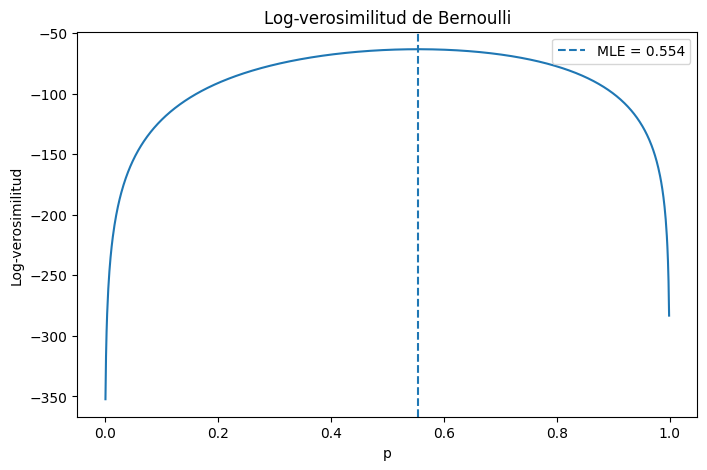

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(grilla, log_lik(grilla, k, n))

plt.axvline(p_hat, linestyle="--", label=f"MLE = {p_hat:.3f}")

plt.xlabel("p")
plt.ylabel("Log-verosimilitud")
plt.title("Log-verosimilitud de Bernoulli")
plt.legend()

plt.show()

### Ejercicio 7 (0.20): MLE de la Normal

Sobre `temperature_2m_max`: (a) `mu_hat` sin usar `.mean()`. (b) `sigma2_hat`, el promedio de las desviaciones al cuadrado. Comparar con NumPy.

In [49]:
temp = clima["temperature_2m_max"]

# a) mu_hat: el promedio, sin usar .mean()
mu_hat = np.sum(temp) / len(temp)

# b) sigma2_hat: promedio de (temp - mu_hat)**2
sigma2_hat = np.sum((temp - mu_hat)**2) / len(temp)

print("mu_hat:", mu_hat)
print("sigma2_hat:", sigma2_hat)
print("sigma_hat:", np.sqrt(sigma2_hat))

# Verificación (descomentar):
assert np.isclose(mu_hat, temp.mean())
assert np.isclose(np.sqrt(sigma2_hat), temp.std(ddof=0))

mu_hat: 26.85978260869566
sigma2_hat: 3.6256651701323253
sigma_hat: 1.9041179506880148


### Ejercicio 8 (0.20): MAP con un prior equivocado

Prior Beta(2, 10): la creencia de alguien que piensa que en Guatemala casi no llueve (1 día de lluvia en 10 imaginarios). Implementar `map_beta` y comparar con el MLE usando los 92 días.

$$\hat{p}_{MAP} = \frac{k + \alpha - 1}{n + \alpha + \beta - 2}$$

In [50]:
def map_beta(k, n, a=2, b=10):
    return (k + a - 1) / (n + a + b - 2)

p_mle = k / n
p_map = map_beta(k, n)

print("MLE:", p_mle)
print("MAP:", p_map)

# Verificación (descomentar):
assert round(map_beta(k, n), 3) == 0.510

MLE: 0.5543478260869565
MAP: 0.5098039215686274


### Ejercicio 9 (0.20): el prior se diluye

Para cada `m` en `[7, 14, 30, 60, 92]`: con los **primeros** `m` días, calcular `k_m`, el MLE, el MAP y la diferencia absoluta. Guardar `(m, mle_m, map_m)` en `resultados` e imprimir la tabla.

In [51]:
ns = [7, 14, 30, 60, 92]
resultados = []

for m in ns:
    k_m = int(clima["llovio"][:m].sum())

    mle_m = k_m / m
    map_m = map_beta(k_m, m)

    resultados.append((m, mle_m, map_m))

    diferencia = abs(mle_m - map_m)

    print(
        f"m={m:2d} | "
        f"MLE={mle_m:.3f} | "
        f"MAP={map_m:.3f} | "
        f"Diferencia={diferencia:.3f}"
    )

# Verificación (descomentar):
difs = [abs(mle_m - map_m) for _, mle_m, map_m in resultados]
assert round(difs[0], 2) == 0.19 and round(difs[-1], 2) == 0.04

m= 7 | MLE=0.429 | MAP=0.235 | Diferencia=0.193
m=14 | MLE=0.286 | MAP=0.208 | Diferencia=0.077
m=30 | MLE=0.467 | MAP=0.375 | Diferencia=0.092
m=60 | MLE=0.633 | MAP=0.557 | Diferencia=0.076
m=92 | MLE=0.554 | MAP=0.510 | Diferencia=0.045


### Ejercicio 10 (0.20): graficar la dilución

Con `resultados`: graficar MLE y MAP contra `m` (dos series con leyenda). El patrón está en el notebook de la sesión 5.

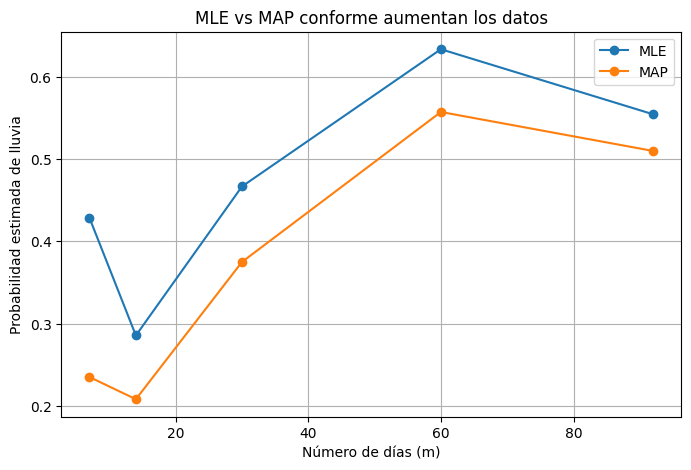

In [52]:
ms = [m for m, mle_m, map_m in resultados]
mles = [mle_m for m, mle_m, map_m in resultados]
maps = [map_m for m, mle_m, map_m in resultados]

plt.figure(figsize=(8, 5))

plt.plot(ms, mles, marker="o", label="MLE")
plt.plot(ms, maps, marker="o", label="MAP")

plt.xlabel("Número de días (m)")
plt.ylabel("Probabilidad estimada de lluvia")
plt.title("MLE vs MAP conforme aumentan los datos")

plt.legend()
plt.grid(True)
plt.show()

## Parte C · Criterio (0.2 pt)

### Ejercicio 11 (0.20)

El prior Beta(2,10) era objetivamente malo para época lluviosa. En 3-4 líneas, **citando los números del ejercicio 9**: ¿qué hicieron los datos con ese prior, a partir de cuántos días dejó de dominar, y qué implica esto para usar regularización (ridge/lasso) en modelos con pocos datos?

_(Responder editando esta celda)_

**Respuesta:** Con pocos datos, el prior sí afectó bastante el resultado. Con 7 días, la diferencia entre el MLE y el MAP era de 0.19, pero desde 14 días ya bajó a alrededor de 0.08 y con 92 días llegó a solo 0.04. Esto muestra que los datos fueron quitándole peso al prior conforme aumentó la información. Lo mismo pasa con ridge o lasso: con pocos datos la regularización puede influir bastante, pero con más datos su efecto relativo disminuye.

## Mini-bitácora de AI (opcional, no penaliza)

Si se usó AI para entender algún concepto, anotar aquí qué se preguntó y qué se entendió. Si no se usó, escribir "No se usó".

- Se usó AI para entender mejor los conceptos de MLE y MAP, especialmente cómo influye el prior cuando hay pocos datos y cómo esa influencia disminuye conforme aumenta la cantidad de observaciones.